# NHL Goals Above Expected — Logistic Regression with L1 Regularization
## Ed Deignan
### INFSCI 1530
### 22 April 2026

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegressionCV, LogisticRegression
from sklearn import metrics
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings('ignore')

np.random.seed(123)

## 1. Load Data

This analysis will be conducted on the **most recent complete season** of **NHL Hockey**, the **2024-2025 Season**
This dataset is at the **Game Level**, meaning data is provided for each skater (non-goalie) on each time on a game-by-game basis with additional breakdowns for their on-ice situation.

Data from MoneyPuck: https://moneypuck.com/data.htm

In [2]:
df = pd.read_csv('2024.csv')
print(df.shape)
df.head(5)

(236120, 157)


,playerId,name,gameId,season,playerTeam,opposingTeam,home_or_away,gameDate,position,situation,...,OffIce_F_xGoals,OffIce_A_xGoals,OffIce_F_shotAttempts,OffIce_A_shotAttempts,xGoalsForAfterShifts,xGoalsAgainstAfterShifts,corsiForAfterShifts,corsiAgainstAfterShifts,fenwickForAfterShifts,fenwickAgainstAfterShifts
0,8481563,Drew Helleson,2024020271,2024,ANA,DET,HOME,20241115,D,other,...,0.000,0.000,0.0,0.0,0.000,0.0,0.0,0.0,0.0,0.0
1,8481563,Drew Helleson,2024020271,2024,ANA,DET,HOME,20241115,D,all,...,3.262,3.208,45.0,43.0,0.000,0.0,0.0,0.0,0.0,0.0
2,8481563,Drew Helleson,2024020271,2024,ANA,DET,HOME,20241115,D,5on5,...,0.504,1.218,23.0,32.0,0.018,0.0,1.0,0.0,1.0,0.0
3,8481563,Drew Helleson,2024020271,2024,ANA,DET,HOME,20241115,D,4on5,...,0.000,0.000,0.0,0.0,0.000,0.0,0.0,0.0,0.0,0.0
4,8481563,Drew Helleson,2024020271,2024,ANA,DET,HOME,20241115,D,5on4,...,0.000,0.000,0.0,0.0,0.000,0.0,0.0,0.0,0.0,0.0


In [3]:
null_count = df.isnull().sum()
print(f"Columns with nulls: {len(null_count[null_count > 0])}")

Columns with nulls: 0


## 2. Build Target Variable

`Goals Above Expected` is a simple differencing metric that measures how well a player performed against their "expected" goal count. For example, a player with an xGoals value of 0.5 would have a +0.5 Goals Above Expected if they score that night, and a -0.5 Goals Above Expected if they did not.

count    166490.000000
mean         -0.002811
std           0.281062
min          -3.217000
25%          -0.068000
50%           0.000000
75%           0.000000
max           2.750000
Name: goalsAboveExpected, dtype: float64

Overperformance Rate: 8.28%


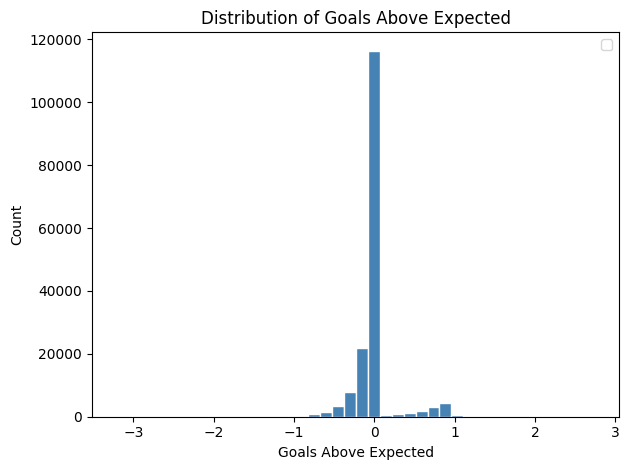

In [4]:
p = df.copy()

# Filter out data entries in which a player has no shifts - not meaningful data
p = p[p['shifts'] > 0]

p['goalsAboveExpected'] = p['I_F_goals'] - p['I_F_xGoals']

## Classify an entry as an "overperformance" if a player has a strictly positive Goals Above Expected value
p['overperform'] = (p['goalsAboveExpected'] > 0).astype(int)

print(p['goalsAboveExpected'].describe())
print(f"\nOverperformance Rate: {p['overperform'].mean():.2%}")

# Plot the distribution of Goals Above Expected
plt.hist(p['goalsAboveExpected'], bins=40, color='steelblue', edgecolor='white')
plt.title('Distribution of Goals Above Expected')
plt.xlabel('Goals Above Expected')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

## 3. Feature Selection

Remove features that either **directly correlate** to `Goals Above Expected` or are otherwise useless in its prediction


In [5]:
# Columns that directly leak the target or are identifiers
REMOVE = {
    'goalsAboveExpected',            # Target features
    'overperform',                   # ^^^
    'I_F_goals',                     # [Player]'s "Individual For Goals" (i.e. goals scored)
    'I_F_points',                    # Points are 2/goal and 1/assist
    'I_F_lowDangerGoals',            # Categorizes goals scored by player
    'I_F_mediumDangerGoals',         # ^^^
    'I_F_highDangerGoals',           # ^^^
    'I_F_reboundGoals',              # ^^^
    'I_F_xGoals',                    # [Player]'s "Expected Goals" (component of target features) 
    'I_F_savedShotsOnGoal',          # When combined with shots on goal, this can leak a player's goal count
    'I_F_savedUnblockedShotAttempts',# ^^^
    'OnIce_F_goals',                 # [Player]'s +/- contribution, which will be incremented by their goals
    'gameScore',                     # Similar to above, game score is influenced by player goals
    'playerId',                      # Identifies player
    'season'                         # 2024-2025 season tag - already unnecessary on a single-season dataset
}

# Keep all quantitaive columns provided they are not set for removal
q_cols = p.select_dtypes(include=[np.number]).columns.tolist()
FEATURES = [v for v in q_cols if v not in REMOVE]

print(f"Total features fed to L1 model: {len(FEATURES)}")
for feat in FEATURES:
    print(feat)

Total features fed to L1 model: 138
gameId
gameDate
icetime
shifts
onIce_xGoalsPercentage
offIce_xGoalsPercentage
onIce_corsiPercentage
offIce_corsiPercentage
onIce_fenwickPercentage
offIce_fenwickPercentage
iceTimeRank
I_F_xOnGoal
I_F_xRebounds
I_F_xFreeze
I_F_xPlayStopped
I_F_xPlayContinuedInZone
I_F_xPlayContinuedOutsideZone
I_F_flurryAdjustedxGoals
I_F_scoreVenueAdjustedxGoals
I_F_flurryScoreVenueAdjustedxGoals
I_F_primaryAssists
I_F_secondaryAssists
I_F_shotsOnGoal
I_F_missedShots
I_F_blockedShotAttempts
I_F_shotAttempts
I_F_rebounds
I_F_freeze
I_F_playStopped
I_F_playContinuedInZone
I_F_playContinuedOutsideZone
penalties
I_F_penalityMinutes
I_F_faceOffsWon
I_F_hits
I_F_takeaways
I_F_giveaways
I_F_lowDangerShots
I_F_mediumDangerShots
I_F_highDangerShots
I_F_lowDangerxGoals
I_F_mediumDangerxGoals
I_F_highDangerxGoals
I_F_scoreAdjustedShotsAttempts
I_F_unblockedShotAttempts
I_F_scoreAdjustedUnblockedShotAttempts
I_F_dZoneGiveaways
I_F_xGoalsFromxReboundsOfShots
I_F_xGoalsFromActualR

## 4. Train / Test Split & Scaling

**80/20** split for `Logistic Regression` Model + Standard Scaling (needed before `L1 Regularization` is applied)

- Given that there are **143** possible features, **L1 Regularization** will zero out features that do not contribute significantly to prediting `Goals Above Expected`

In [6]:
X = p[FEATURES].fillna(0)
y = p['overperform'].to_numpy()

# Create train/test splits
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y, shuffle=True
)

# Standard scaling for effective L1 Regularization
scaler = StandardScaler()
X_train = scaler.fit_transform(X_tr)
X_test  = scaler.transform(X_te) # Do not fit scaler to the test data!

# Show train/test values
print(f"Train: {X_train.shape[0]}; Test: {X_test.shape[0]}")

# Ensure that the training data keeps the expected proportion of Goals Above Expected overperformance
print(f"Train class balance: {y_tr.mean():.2%} overperform")

Train: 133192; Test: 33298
Train class balance: 8.28% overperform


## 5. L1 Logistic Regression with 5-Fold Cross-Validation

**L1 Regularization** relies on a hyperparamter `lambda` that should be tuned for optimal results
Lambda can be tuned with `Cross Validation` using **sklearn's** `LogisticRegressionCV` model: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegressionCV.html

`NOTE:` For tuning lambda, sklearn uses **C**, the inverse of **lambda**

In [7]:
# Establish values of lambda to be tested through cross validation
C_grid = np.logspace(-4, -1, 10)

# Build the regression model
cv_model = LogisticRegressionCV(
    Cs=C_grid,
    penalty='l1',
    solver='saga',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42), # "n_splits = 5" ensures 5-folds with "shuffle" giving randomized data in each
    scoring='roc_auc', # evaluation metric for a classification setting - should optimize ROC curve for later visualization!
    max_iter=100,
    random_state=42,
    n_jobs=-1
)

cv_model.fit(X_train, y_tr)

# Return the optimal value of C
best_C = cv_model.C_[0]
print(f"Best C selected by 5-fold CV: {best_C:.5f}")
print(f"Equivalent lambda: {1/best_C:.5f}")

Best C selected by 5-fold CV: 0.10000
Equivalent lambda: 10.00000


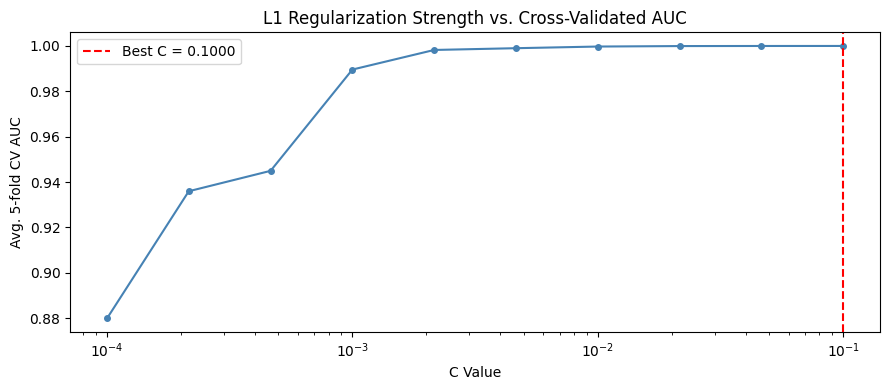

In [8]:
# Plot mean AUC across folds for each C value
mean_scores = cv_model.scores_[1].mean(axis=0) 

plt.figure(figsize=(9, 4))
plt.semilogx(cv_model.Cs_, mean_scores, marker='o', markersize=4, color='steelblue')
plt.axvline(best_C, color='red', linestyle='--', label=f'Best C = {best_C:.4f}')
plt.xlabel('C Value')
plt.ylabel('Avg. 5-fold CV AUC')
plt.title('L1 Regularization Strength vs. Cross-Validated AUC')
plt.legend()
plt.tight_layout()
plt.show()

There is a notable 'elbow' in the AUC vs. C plot near **C = 0.001**. To ensure a strong regularization, the lowest value of **C** (i.e. largest value of **lambda**) before diminishing returns begin will be selected

In [9]:
tuned_model = LogisticRegression(
    C=0.001,
    penalty='l1',
    solver = 'saga',
    max_iter = 100,
    random_state=42,
    n_jobs = -1
)

tuned_model.fit(X_train, y_tr)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'l1'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.001
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass`

## 6. Feature Interpretation via L1 Coefficients

Insignificant coefficients are **zeroed** through regularization, meaning any remaining features will contribute strongly to the prediction of `Goals Above Expected`.
Through this process, feature selection has been automated and the key identifiers for an **overperformance** can be directly observed


In [16]:
coef_series = pd.Series(tuned_model.coef_[0], index=FEATURES)
nonzero = coef_series[coef_series != 0].sort_values()

print(f"Features surviving L1 (non-zero coef): {len(nonzero)} / {len(FEATURES)}")
print(f"Features zeroed out by L1:             {len(FEATURES) - len(nonzero)}")
print(f"\nRemaining features:\n{nonzero.to_string()}")

Features surviving L1 (non-zero coef): 21 / 138
Features zeroed out by L1:             117

Remaining features:
I_F_playContinuedOutsideZone                          -1.651873
I_F_playContinuedInZone                               -1.515985
I_F_freeze                                            -0.901354
I_F_rebounds                                          -0.611032
I_F_primaryAssists                                    -0.193937
I_F_secondaryAssists                                  -0.174299
I_F_xGoalsFromActualReboundsOfShots                   -0.052542
I_F_playStopped                                       -0.026228
I_F_xRebounds                                          0.059609
I_F_lowDangerxGoals                                    0.068161
I_F_xGoals_with_earned_rebounds_scoreAdjusted          0.074358
I_F_mediumDangerShots                                  0.077663
I_F_xGoals_with_earned_rebounds_scoreFlurryAdjusted    0.096718
OnIce_F_highDangerGoals                                0

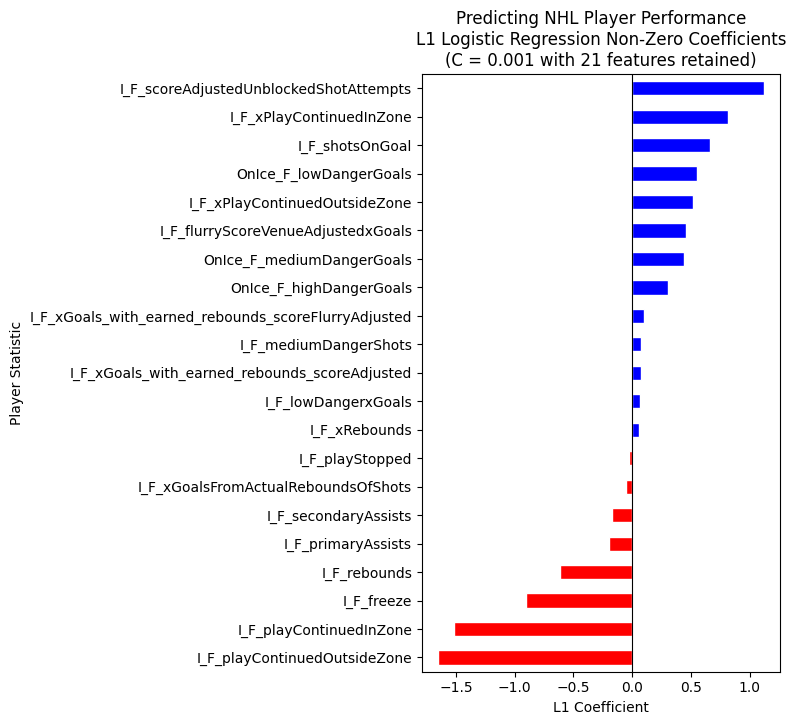

In [18]:
# Horizontal bar chart of surviving coefficients
fig, ax = plt.subplots(figsize=(8, max(5, len(nonzero) * 0.35)))

colors = ['blue' if v > 0 else 'red' for v in nonzero.values]
nonzero.plot(kind='barh', ax=ax, color=colors, edgecolor='white')

ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('L1 Coefficient')
ax.set_ylabel('Player Statistic')
ax.set_title(f'Predicting NHL Player Performance\n'
             f'L1 Logistic Regression Non-Zero Coefficients\n'
             f'(C = 0.001 with {len(nonzero)} features retained)')
plt.tight_layout()
plt.show()

## 7. Test Set Evaluation

Evaluation metrics for the `L1 Logistic Regression` model on the test data set

In [12]:
y_pred = tuned_model.predict(X_test)
y_pred_prob = tuned_model.predict_proba(X_test)[:, 1]

print("Test Set Performance")
print(f"Accuracy : {metrics.accuracy_score(y_te, y_pred):.4f}")
print(f"ROC-AUC  : {metrics.roc_auc_score(y_te, y_pred_prob):.4f}")
print(f"\n{metrics.classification_report(y_te, y_pred)}")

Test Set Performance
Accuracy : 0.9634
ROC-AUC  : 0.9954

              precision    recall  f1-score   support

           0       0.97      1.00      0.98     30540
           1       0.92      0.61      0.73      2758

    accuracy                           0.96     33298
   macro avg       0.94      0.80      0.86     33298
weighted avg       0.96      0.96      0.96     33298



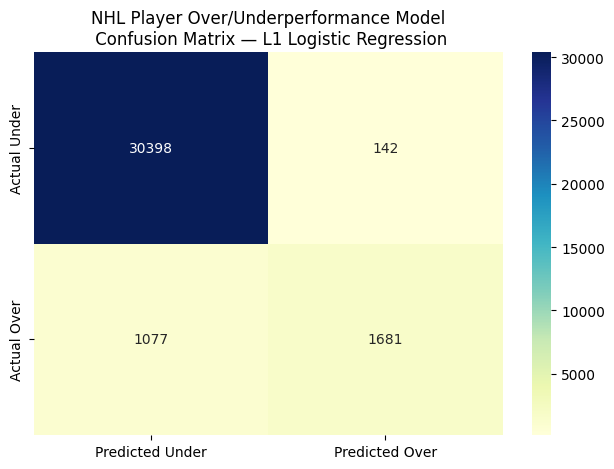

In [13]:
# Confusion matrix
cnf = metrics.confusion_matrix(y_te, y_pred)
sns.heatmap(pd.DataFrame(cnf,
                index=['Actual Under', 'Actual Over'],
                columns=['Predicted Under', 'Predicted Over']),
            annot=True, cmap='YlGnBu', fmt='g')
plt.title('NHL Player Over/Underperformance Model\n Confusion Matrix — L1 Logistic Regression')
plt.tight_layout()
plt.show()